# Data Cleaning and Model Testing

### Team 26: Anti-Sugar Rush

In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import os
import re
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
import matplotlib.pyplot as plt
import joblib
import json

In [2]:
#data extraction path and folders
#NOTE: Works under assumption that data is in user's downloads folder
manchester_path = os.path.expanduser('~/Downloads/ManchesterCSCoordinatedDiabetesStudy-V1.0.1/sharpic-ManchesterCSCoordinatedDiabetesStudy-a9e8025')
manchester_folders = ['Glucose Data', 'Sleep Data', 'Insulin Data/Basal Data', 'Insulin Data/Bolus Data', 'Nutrition Data', 'Activity Data']

In [3]:
#function to extract user id from file name
def get_id(file):

    #searching for 4 digit id
    match = re.search(r"\d{4}", file)

    #returning id if found
    return match.group() if match else None
    
#function to load all the CSVs in a folder
def load_folder_data(folder_path):

    all_users = [] #initialization list to collect all user data in one table

    #for loop to read each csv and append user data to all-users
    for file in os.listdir(folder_path):

        #checking file is a csv since folder may contain other file types
        if file.endswith('.csv') and "sleeptime" not in file:

            df = pd.read_csv((os.path.join(folder_path, file))) #reading csv

            mask = df.columns.str.contains("^Unnamed")  #find unnamed columns caused by unclean CSV files
            df = df.loc[:, ~mask] #filtering to only include named columns
            
            file_id = get_id(file) #extracting id
            df['id'] = file_id #setting id as a column
            
            all_users.append(df) #appending to all_users list

    return pd.concat(all_users) #returning dataframe with all users data

In [4]:
#initializing dictionary for all folder dataframes
df_dict = {}

#extracting data from each file
for folder in manchester_folders:
    
    file_path = os.path.join(manchester_path, folder) #creating folder specific data path
    df_dict[folder] = load_folder_data(file_path) #setting folder as key and dataframe as value

#testing to ensure data comes through correctly
df_dict['Glucose Data'].head()

,bg_ts,value,id
0,01/10/2023 00:04,7.5,2301
1,01/10/2023 00:09,8.0,2301
2,01/10/2023 00:14,8.6,2301
3,01/10/2023 00:19,9.2,2301
4,01/10/2023 00:24,9.7,2301


In [5]:
#function to create 15 minute time buckets
def create_time_buckets(df, ts, freq = '15min'):

    df[ts] = pd.to_datetime(df[ts], errors="coerce") #convert column to date time type
    df['time_bucket'] = df[ts].dt.floor(freq) #force time stamps into 15 minute buckets

    return df

In [6]:
glucose_df = df_dict['Glucose Data'] #extracting glucose df

glucose_df['glucose'] =  glucose_df['value'] * 18 #converting glucose from mmol/L to mg/dL

glucose_df = create_time_buckets(glucose_df, 'bg_ts') #creating time buckets

#aggregating to only have one entry per time stamp
glucose_df = glucose_df.groupby(['id', 'time_bucket']).agg({
    'glucose': 'last',
}).reset_index()

print(glucose_df.head())

     id         time_bucket  glucose
0  2301 2023-01-10 00:00:00    154.8
1  2301 2023-01-10 00:15:00    181.8
2  2301 2023-01-10 00:30:00    214.2
3  2301 2023-01-10 00:45:00    261.0
4  2301 2023-01-10 01:00:00    261.0


In [7]:
sleep_df = df_dict['Sleep Data'] #extracting sleep df

sleep_df = create_time_buckets(sleep_df, 'sleep_ts') #creating time buckets

#aggregating to only have one entry per time stamp
sleep_df = sleep_df.groupby(['id', 'time_bucket']).agg({
    'heart_rate': 'last'
}).reset_index()

print(sleep_df.head())

     id         time_bucket  heart_rate
0  2301 2023-01-11 00:00:00          79
1  2301 2023-01-11 00:15:00          80
2  2301 2023-01-11 00:30:00          76
3  2301 2023-01-11 00:45:00          75
4  2301 2023-01-11 01:00:00          76


In [8]:
activity_df = df_dict['Activity Data'] #extracting activity df

activity_df =  create_time_buckets(activity_df, 'activity_ts') #creating time buckets

#changing categorical values to numbers
activity_df['intensity_num'] = activity_df['intensity'].replace({'HIGHLY_ACTIVE': 2, 'ACTIVE': 1, 'SEDENTARY': 0})
activity_df['activity_type_num'] = activity_df['activity_type'].replace({'SEDENTARY': 0, 'GENERIC': 1, 'UNMONITORED': 2, 'WALKING' : 3, 'WHEELCHAIR_PUSHING' : 4, 'RUNNING' : 5})

#calculating percent active time out of 15 minutes
activity_df['percent_active'] = activity_df['active_time_s'] / activity_df['duration_s']

#converting Kcal to cal
activity_df['active_cal'] = activity_df['active_Kcal'] * 1000

#aggregating to only have one entry per time stamp
activity_df = activity_df.groupby(['id', 'time_bucket']).agg({
    'active_cal': 'sum',
    'percent_active': 'mean',
    'intensity_num' : 'max',
    'activity_type_num' : 'max'
}).reset_index()

print(activity_df.head())

C:\Users\freya\AppData\Local\Temp\ipykernel_43868\1317695620.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  activity_df['intensity_num'] = activity_df['intensity'].replace({'HIGHLY_ACTIVE': 2, 'ACTIVE': 1, 'SEDENTARY': 0})
C:\Users\freya\AppData\Local\Temp\ipykernel_43868\1317695620.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  activity_df['activity_type_num'] = activity_df['activity_type'].replace({'SEDENTARY': 0, 'GENERIC': 1, 'UNMONITORED': 2, 'WALKING' : 3, 'WHEELCHAIR_PUSHING' : 4, 'RUNNING' : 5})


     id         time_bucket  active_cal  percent_active  intensity_num  \
0  2301 2023-01-10 05:45:00           0             1.0              0   
1  2301 2023-01-10 06:00:00           0             1.0              0   
2  2301 2023-01-10 06:15:00           0             1.0              0   
3  2301 2023-01-10 06:30:00           0             1.0              0   
4  2301 2023-01-10 06:45:00           0             1.0              0   

   activity_type_num  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  


In [9]:
basal_df = df_dict['Insulin Data/Basal Data'] #extracting basal insulin df

basal_df =  create_time_buckets(basal_df, 'basal_ts') #creating time buckets

#changing categorical values to numbers
basal_df['insulin_kind'] = basal_df['insulin_kind'].replace({'R': 0, 'L': 1})

#aggregating to only have one entry per time stamp
basal_df = basal_df.groupby(['id', 'time_bucket']).agg({
    'basal_dose': 'sum',
    'insulin_kind': 'last'
}).reset_index()


print(basal_df.head())

     id         time_bucket  basal_dose  insulin_kind
0  2301 2023-01-12 00:00:00       4.909             0
1  2301 2023-01-12 00:30:00       0.000             0
2  2301 2023-01-12 00:45:00       0.230             0
3  2301 2023-01-12 01:00:00       0.638             0
4  2301 2023-01-12 01:15:00       1.045             0


C:\Users\freya\AppData\Local\Temp\ipykernel_43868\1141971177.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  basal_df['insulin_kind'] = basal_df['insulin_kind'].replace({'R': 0, 'L': 1})


In [10]:
bolus_df = df_dict['Insulin Data/Bolus Data'] #extracting bolus insulin df

bolus_df =  create_time_buckets(bolus_df, 'bolus_ts') #creating time buckets

#aggregating to only have one entry per time stamp
bolus_df = bolus_df.groupby(['id', 'time_bucket']).agg({
    'bolus_dose': 'sum'
}).reset_index()

print(bolus_df.head())

     id         time_bucket  bolus_dose
0  2301 2023-01-12 12:30:00        2.31
1  2301 2023-01-12 19:15:00        5.87
2  2301 2023-01-12 22:45:00        0.59
3  2301 2023-01-12 23:15:00        0.06
4  2301 2023-02-12 09:30:00        1.29


In [11]:
nutrition_df = df_dict['Nutrition Data'] #extracting nutrition df

nutrition_df =  create_time_buckets(nutrition_df, 'meal_ts') #creating time buckets

#aggregating to only have one entry per time stamp
nutrition_df = nutrition_df.groupby(['id', 'time_bucket']).agg({
    'carbs_g': 'sum',
    'prot_g': 'sum',
    'fat_g': 'sum',
    'fibre_g': 'sum',
}).reset_index()

print(nutrition_df.head())

     id         time_bucket  carbs_g  prot_g  fat_g  fibre_g
0  2301 2023-10-22 10:00:00      0.0     0.0    1.0      0.0
1  2301 2023-10-22 12:00:00     19.0    50.0   32.0     10.0
2  2301 2023-10-22 17:15:00     10.0     0.0    0.0      0.0
3  2301 2023-10-23 00:00:00      0.0     0.0    1.0      0.0
4  2301 2023-10-23 14:45:00     54.0    22.0   30.0      0.0


C:\Users\freya\AppData\Local\Temp\ipykernel_43868\1110972669.py:4: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[ts] = pd.to_datetime(df[ts], errors="coerce") #convert column to date time type


In [12]:
#combining all datasets into one dataframe
combined_df = pd.merge(glucose_df[glucose_df['time_bucket'].notna()], activity_df[activity_df['time_bucket'].notna()], how = 'left', on = ['id', 'time_bucket'])
combined_df = pd.merge(combined_df, sleep_df[sleep_df['time_bucket'].notna()], how = 'left', on = ['id', 'time_bucket'])
combined_df = pd.merge(combined_df, basal_df[basal_df['time_bucket'].notna()], how = 'left', on = ['id', 'time_bucket'])
combined_df = pd.merge(combined_df, bolus_df[bolus_df['time_bucket'].notna()], how = 'left', on = ['id', 'time_bucket'])
combined_df = pd.merge(combined_df, nutrition_df[nutrition_df['time_bucket'].notna()], how = 'left', on = ['id', 'time_bucket'])

combined_df.head()

,id,time_bucket,glucose,active_cal,percent_active,intensity_num,activity_type_num,heart_rate,basal_dose,insulin_kind,bolus_dose,carbs_g,prot_g,fat_g,fibre_g
0,2301,2023-01-10 00:00:00,154.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2301,2023-01-10 00:15:00,181.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2301,2023-01-10 00:30:00,214.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2301,2023-01-10 00:45:00,261.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2301,2023-01-10 01:00:00,261.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
#dropping rows with no glucose data and filling na with 0

combined_df = combined_df.dropna(subset=['glucose'])
combined_df = combined_df.fillna(0)

In [14]:
#initializing list to store dfs at a user level
all_users_dict = {}
ids_list = combined_df['id'].unique()

#looping through all user ids
for ids in ids_list:

    ##creating user specific df
    usr_df = combined_df[combined_df['id'] == ids].copy()
    usr_df = usr_df.sort_values('time_bucket')

    #removing entries that do not have an hour of past history
    usr_df['valid_history'] = usr_df['time_bucket'] - usr_df['time_bucket'].shift(4)
    usr_df = usr_df[usr_df['valid_history'] == pd.Timedelta(minutes=60)]
    usr_df = usr_df.drop(columns = ['valid_history'])

    #creating lag features
    for lag in range(1, 5):
        usr_df[f'glucose_lag_{lag}'] = usr_df['glucose'].shift(lag)
        usr_df[f'carbs_g_lag_{lag}'] = usr_df['carbs_g'].shift(lag)
        usr_df[f'fat_g_lag_{lag}'] = usr_df['fat_g'].shift(lag)
        usr_df[f'prot_g_lag_{lag}'] = usr_df['prot_g'].shift(lag)
        usr_df[f'fibre_g_lag_{lag}'] = usr_df['fibre_g'].shift(lag)
        usr_df[f'basal_dose_lag_{lag}'] = usr_df['basal_dose'].shift(lag)
        usr_df[f'bolus_dose_lag_{lag}'] = usr_df['bolus_dose'].shift(lag)
        usr_df[f'active_cal_lag_{lag}'] = usr_df['active_cal'].shift(lag)

    #creating aggregate features using lag features
    usr_df['glucose_mean_1hr'] = (usr_df['glucose'].shift(1).rolling(4).mean())
    usr_df['carbs_sum_1hr'] = usr_df['carbs_g'].shift(1).rolling(4).sum()
    usr_df['fat_sum_1hr'] = usr_df['fat_g'].shift(1).rolling(4).sum()
    usr_df['prot_sum_1hr'] = usr_df['prot_g'].shift(1).rolling(4).sum()
    usr_df['fibre_sum_1hr'] = usr_df['fibre_g'].shift(1).rolling(4).sum()
    usr_df['basal_dose_sum_1hr'] = usr_df['basal_dose'].shift(1).rolling(4).sum()
    usr_df['bolus_dose_sum_1hr'] = usr_df['bolus_dose'].shift(1).rolling(4).sum()
    usr_df['active_cal_sum_1hr'] = usr_df['active_cal'].shift(1).rolling(4).sum()

    #creating model target which is the glucose an hour in the future
    usr_df['target'] = usr_df['glucose'].shift(-4)

    #dropping all rows with nulls
    usr_df = usr_df.dropna()

    #storing user dataframes in dictionary
    all_users_dict[ids] = usr_df

#testing to ensure dfs are stored correctly with new features
print(all_users_dict['2305'].head())

         id         time_bucket  glucose  active_cal  percent_active  \
14004  2305 2023-01-12 02:00:00    208.8     31000.0        0.666667   
14005  2305 2023-01-12 02:15:00    216.0     34000.0        1.000000   
14006  2305 2023-01-12 02:30:00    214.2     58000.0        1.000000   
14007  2305 2023-01-12 02:45:00    217.8     23000.0        1.000000   
14008  2305 2023-01-12 03:00:00    219.6     37000.0        1.000000   

       intensity_num  activity_type_num  heart_rate  basal_dose  insulin_kind  \
14004            2.0                4.0       101.0         0.0           0.0   
14005            2.0                4.0        99.0         0.0           0.0   
14006            2.0                4.0        86.0         0.0           0.0   
14007            1.0                4.0        97.0         0.0           0.0   
14008            2.0                3.0        89.0         0.0           0.0   

       ...  active_cal_lag_4  glucose_mean_1hr  carbs_sum_1hr  fat_sum_1hr  \
14

In [15]:
#initializing train, val, and test lists
train_list, val_list, test_list = [], [], []

#looping through ids
for ids in ids_list:

    n = len(all_users_dict[ids]) #finding user df size
    train_end = int(0.7 * n) #finding train end/val start
    val_end   = int(0.85 * n) #finding val end/test start

    #appending splits to relevent list
    train_list.append(all_users_dict[ids].iloc[:train_end])
    val_list.append(all_users_dict[ids].iloc[train_end:val_end])
    test_list.append(all_users_dict[ids].iloc[val_end:])

#concatenating all values into one dataframe
train_df = pd.concat(train_list)
val_df   = pd.concat(val_list)
test_df  = pd.concat(test_list)

#setting feature_cols to list sto exclude id, time_bucket, and target
feature_cols = train_df.columns[2:-1]
print(feature_cols)

Index(['glucose', 'active_cal', 'percent_active', 'intensity_num',
       'activity_type_num', 'heart_rate', 'basal_dose', 'insulin_kind',
       'bolus_dose', 'carbs_g', 'prot_g', 'fat_g', 'fibre_g', 'glucose_lag_1',
       'carbs_g_lag_1', 'fat_g_lag_1', 'prot_g_lag_1', 'fibre_g_lag_1',
       'basal_dose_lag_1', 'bolus_dose_lag_1', 'active_cal_lag_1',
       'glucose_lag_2', 'carbs_g_lag_2', 'fat_g_lag_2', 'prot_g_lag_2',
       'fibre_g_lag_2', 'basal_dose_lag_2', 'bolus_dose_lag_2',
       'active_cal_lag_2', 'glucose_lag_3', 'carbs_g_lag_3', 'fat_g_lag_3',
       'prot_g_lag_3', 'fibre_g_lag_3', 'basal_dose_lag_3', 'bolus_dose_lag_3',
       'active_cal_lag_3', 'glucose_lag_4', 'carbs_g_lag_4', 'fat_g_lag_4',
       'prot_g_lag_4', 'fibre_g_lag_4', 'basal_dose_lag_4', 'bolus_dose_lag_4',
       'active_cal_lag_4', 'glucose_mean_1hr', 'carbs_sum_1hr', 'fat_sum_1hr',
       'prot_sum_1hr', 'fibre_sum_1hr', 'basal_dose_sum_1hr',
       'bolus_dose_sum_1hr', 'active_cal_sum_1hr'],
  

In [16]:
#creating param grids for model hyperparameter tuning

#from: https://www.geeksforgeeks.org/machine-learning/what-is-ridge-regression/
ridge_param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100, 500]}

#from: https://www.geeksforgeeks.org/machine-learning/how-to-tune-a-decision-tree-in-hyperparameter-tuning/
decision_tree_param_grid = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#from: https://www.geeksforgeeks.org/machine-learning/xgboost-for-regression/
xgboost_param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)

#setting param and model list
param_list = [ridge_param_grid, decision_tree_param_grid, xgboost_param_grid]
model_list = [Ridge(), DecisionTreeRegressor(random_state=42), xgb_model]

In [17]:
#referenced: https://www.geeksforgeeks.org/machine-learning/what-is-ridge-regression/ to build function

#creaying best model function to be able to run grid searches and save best  models
def best_model(model, param_grid, X_train, y_train):
    
    grid = GridSearchCV(model, param_grid, cv=5, scoring="neg_mean_squared_error")
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    return best_model


In [18]:
# initializing best models list
best_models = []

#setting sample train dataset. The sample uses omly a single user's data to save time
train_2301 = train_df[train_df['id'] == '2301'].copy()
X_train_2301 = train_2301[feature_cols]
y_train_2301 = train_2301['target']

#looping through the three models in model_list
for i in range(3):
    best_models.append(best_model(model_list[i], param_list[i], X_train_2301, y_train_2301))

In [19]:
#create model performance testing function
def model_performance(train_df, test_df, feature_cols, model):

    #creating copy of train_df and adding blank prediction column
    test = test_df.copy()
    test['prediction'] = np.nan

    #creating train df copy
    train = train_df.copy()

    #initialization model dictionary and metrics list
    model_dict = {}
    mae_list = []
    rmse_list = []
    r2_list = []
    

    #looping through ids to train individual user models
    ids_list = train_df['id'].unique()
    for ids in ids_list:

        #creating usr train and test dfs
        usr_train = train[train['id'] == ids].copy()
        usr_test = test[test['id'] == ids].copy()

        #creating x_train and y_train
        X_train = usr_train[feature_cols]
        y_train = usr_train['target']

        #creating x_test and y_test
        X_test = usr_test[feature_cols]
        y_test = usr_test['target']

        m = clone(model) #cloning model for each user to prevent overwriting the model each time it's trained
        m.fit(X_train, y_train) #training model
        m.feature_cols = feature_cols #saving feature cols to each model
        model_dict[ids] = m #writing to model_dict

        y_pred = m.predict(X_test) #predicting for test data
        test.loc[usr_test.index, 'prediction'] = y_pred #saving prediction to test data

        #calculating performance metrics and appending to list
        mae_list.append(mean_absolute_error(y_test, y_pred))
        rmse_list.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        r2_list.append(r2_score(y_test, y_pred))

    #finding mean performance metrics after training each user model
    print(np.mean(mae_list), np.mean(rmse_list), np.mean(r2_list))
    return test, model_dict, np.mean(mae_list), np.mean(rmse_list), np.mean(r2_list)

In [20]:
print(feature_cols)

#train models with validation set and calculate average performance metrics (mae, rmse, and r^2)
val_lin = model_performance(train_df, val_df, feature_cols, LinearRegression())
val_ridge = model_performance(train_df, val_df, feature_cols, best_models[0])
val_tree = model_performance(train_df, val_df, feature_cols, best_models[1])
val_xgb = model_performance(train_df, val_df, feature_cols, best_models[2])

Index(['glucose', 'active_cal', 'percent_active', 'intensity_num',
       'activity_type_num', 'heart_rate', 'basal_dose', 'insulin_kind',
       'bolus_dose', 'carbs_g', 'prot_g', 'fat_g', 'fibre_g', 'glucose_lag_1',
       'carbs_g_lag_1', 'fat_g_lag_1', 'prot_g_lag_1', 'fibre_g_lag_1',
       'basal_dose_lag_1', 'bolus_dose_lag_1', 'active_cal_lag_1',
       'glucose_lag_2', 'carbs_g_lag_2', 'fat_g_lag_2', 'prot_g_lag_2',
       'fibre_g_lag_2', 'basal_dose_lag_2', 'bolus_dose_lag_2',
       'active_cal_lag_2', 'glucose_lag_3', 'carbs_g_lag_3', 'fat_g_lag_3',
       'prot_g_lag_3', 'fibre_g_lag_3', 'basal_dose_lag_3', 'bolus_dose_lag_3',
       'active_cal_lag_3', 'glucose_lag_4', 'carbs_g_lag_4', 'fat_g_lag_4',
       'prot_g_lag_4', 'fibre_g_lag_4', 'basal_dose_lag_4', 'bolus_dose_lag_4',
       'active_cal_lag_4', 'glucose_mean_1hr', 'carbs_sum_1hr', 'fat_sum_1hr',
       'prot_sum_1hr', 'fibre_sum_1hr', 'basal_dose_sum_1hr',
       'bolus_dose_sum_1hr', 'active_cal_sum_1hr'],
  

In [21]:
#set second feature list, removing individual lag features and keeping only aggregate lag features
feature_cols2 = [feat for feat in feature_cols if 'lag' not in feat]
print(feature_cols2)

#train models with validation set and calculate average performance metrics (mae, rmse, and r^2)
val_lin2 = model_performance(train_df, val_df, feature_cols2, LinearRegression())
val_ridge2 = model_performance(train_df, val_df, feature_cols2, best_models[0])
val_tree2 = model_performance(train_df, val_df, feature_cols2, best_models[1])
val_xgb2 = model_performance(train_df, val_df, feature_cols2, best_models[2])

['glucose', 'active_cal', 'percent_active', 'intensity_num', 'activity_type_num', 'heart_rate', 'basal_dose', 'insulin_kind', 'bolus_dose', 'carbs_g', 'prot_g', 'fat_g', 'fibre_g', 'glucose_mean_1hr', 'carbs_sum_1hr', 'fat_sum_1hr', 'prot_sum_1hr', 'fibre_sum_1hr', 'basal_dose_sum_1hr', 'bolus_dose_sum_1hr', 'active_cal_sum_1hr']
28.36505276044616 38.42435613842736 0.3808507809590451
28.413425125394586 38.49645948585145 0.37862728552640385
31.846430125595855 43.218648701965925 0.2246383164692171
27.919532672012537 38.15968586209982 0.3901826866935622


In [22]:
#train models with training data set and calculate average performance metrics (mae, rmse, and r^2)
test_lin = model_performance(train_df, test_df, feature_cols, LinearRegression())
test_xgb = model_performance(train_df, test_df, feature_cols, best_models[2])

27.88336942937328 37.3029549257438 0.3966106891938108
27.883428409975558 37.18117523391038 0.39632782003208256


In [24]:
#concatentating datasets to set up for visualization
visuals_lin_df =  pd.concat([val_lin[0], test_lin[0]])
visuals_xgb_df =  pd.concat([val_xgb[0], test_xgb[0]])

#filtering for last day of data to prevent overwhelming the graph
visuals_lin_df = visuals_lin_df[visuals_lin_df['id'] == '2305'].tail(80)
visuals_xgb_df = visuals_xgb_df[visuals_xgb_df['id'] == '2305'].tail(80)

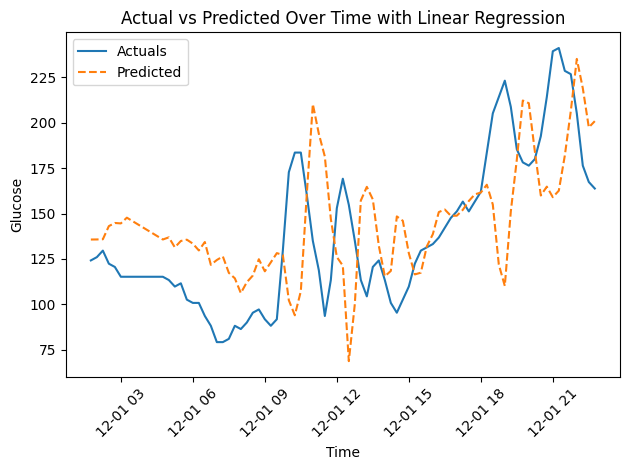

In [25]:
#creating linear regression graph
plt.figure()

plt.plot(visuals_lin_df['time_bucket'], visuals_lin_df['target'], label='Actuals')
plt.plot(visuals_lin_df['time_bucket'], visuals_lin_df['prediction'], linestyle='--', label='Predicted')

plt.xlabel('Time')
plt.ylabel('Glucose')
plt.title('Actual vs Predicted Over Time with Linear Regression')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('glucose_prediction_plot_linreg.png')
plt.show()

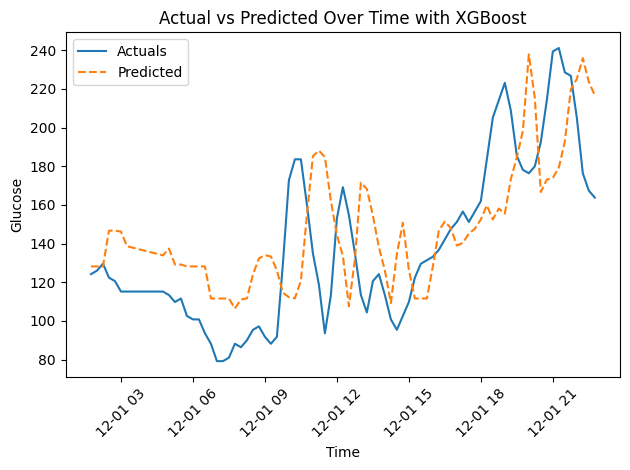

In [26]:
#creating xgboost graph
plt.figure()

plt.plot(visuals_xgb_df['time_bucket'], visuals_xgb_df['target'], label='Actuals')
plt.plot(visuals_xgb_df['time_bucket'], visuals_xgb_df['prediction'], linestyle='--', label='Predicted')

plt.xlabel('Time')
plt.ylabel('Glucose')
plt.title('Actual vs Predicted Over Time with XGBoost')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('glucose_prediction_plot_xgboost.png')
plt.show()

In [27]:
#function to predict user_glucose (used in glucose prediction tool)
def predict_glucose(model_dict, user_input, user_history, user_id = '2405'):

    #turning user input dictionary into a pandas DataFrame
    df = pd.DataFrame([user_input])

    #calling the user's model from the model dictionary as each model is trained on only one user
    model = model_dict[user_id]

    #initializing aggregate columns
    df['glucose_mean_1hr'] = 0 
    df['carbs_sum_1hr'] = 0 
    df['fat_sum_1hr'] = 0 
    df['prot_sum_1hr'] = 0 
    df['fibre_sum_1hr'] = 0 
    df['basal_dose_sum_1hr'] = 0 
    df['bolus_dose_sum_1hr'] = 0 
    df['active_cal_sum_1hr'] = 0 

    #create lag features using the user's last hour of data stored in user_history
    for i in range(4):
        df[f'glucose_lag_{i+1}'] = user_history['glucose'].iloc[i]
        df[f'carbs_g_lag_{i+1}'] = user_history['carbs_g'].iloc[i]
        df[f'fat_g_lag_{i+1}'] = user_history['fat_g'].iloc[i]
        df[f'prot_g_lag_{i+1}'] = user_history['prot_g'].iloc[i]
        df[f'fibre_g_lag_{i+1}'] = user_history['fibre_g'].iloc[i]
        df[f'basal_dose_lag_{i+1}'] = user_history['basal_dose'].iloc[i]
        df[f'bolus_dose_lag_{i+1}'] = user_history['bolus_dose'].iloc[i]
        df[f'active_cal_lag_{i+1}'] = user_history['active_cal'].iloc[i]

        df['glucose_mean_1hr'] += user_history['glucose'].iloc[i]
        df['carbs_sum_1hr'] += user_history['carbs_g'].iloc[i]
        df['fat_sum_1hr'] += user_history['fat_g'].iloc[i]
        df['prot_sum_1hr'] += user_history['prot_g'].iloc[i]
        df['fibre_sum_1hr'] += user_history['fibre_g'].iloc[i]
        df['basal_dose_sum_1hr'] += user_history['basal_dose'].iloc[i]
        df['bolus_dose_sum_1hr'] += user_history['bolus_dose'].iloc[i]
        df['active_cal_sum_1hr'] += user_history['active_cal'].iloc[i]

    df['glucose_mean_1hr'] = df['glucose_mean_1hr']/4

    #calling the feature columns stored in the model
    feature_cols = model.feature_cols

    #checking to make sure all columns used in model are present in user_input df
    for col in feature_cols:
        if col not in df.columns:
            #setting to 0 if missing to prevent model errors
            df[col] = 0

    #setting columns in correct order to prevent error and remove columns not used in model training
    df = df[feature_cols]

    #model prediction
    prediction = model.predict(df)
    return prediction

In [28]:
#setting example user_history, user_inputs, and results
user_history = combined_df[combined_df['id'] == '2305'].iloc[-9:-5].copy()

user_inputs = combined_df[combined_df['id'] == '2305'].iloc[-5].to_dict()
del user_inputs['time_bucket']

result = combined_df[combined_df['id'] == '2305']['glucose'].iloc[-1]

print(user_history)
print(user_inputs)
print(result)

#saving example models_dict
models_dict = test_lin[1]

#exporting example files
joblib.dump(models_dict, "all_models.pkl")
with open("user_inputs.json", "w") as f:
    json.dump(user_inputs, f)
user_history.to_csv("user_history.csv", index=False)

         id         time_bucket  glucose  active_cal  percent_active  \
16224  2305 2024-12-01 21:45:00    214.2         0.0             0.0   
16225  2305 2024-12-01 22:00:00    239.4         0.0             0.0   
16226  2305 2024-12-01 22:15:00    241.2         0.0             0.0   
16227  2305 2024-12-01 22:30:00    228.6         0.0             0.0   

       intensity_num  activity_type_num  heart_rate  basal_dose  insulin_kind  \
16224            0.0                0.0         0.0         0.0           0.0   
16225            0.0                0.0         0.0         0.0           0.0   
16226            0.0                0.0         0.0         0.0           0.0   
16227            0.0                0.0         0.0         0.0           0.0   

       bolus_dose  carbs_g  prot_g  fat_g  fibre_g  
16224         0.0      0.0     0.0    0.0      0.0  
16225         0.0      0.0     0.0    0.0      0.0  
16226         0.0      0.0     0.0    0.0      0.0  
16227         0.0    

In [ ]:
#test function
print(predict_glucose(models_dict, user_inputs, user_history))